<a href="https://colab.research.google.com/github/usama488/Data-science/blob/main/Employee_Attrition_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Employee Attrition Prediction System**

# **Business Problem:**  
# The HR department is experiencing increasing employee attrition, leading to higher hiring and training costs along with productivity loss. The goal is to identify employees likely to leave, understand the key factors driving attrition, and enable the company to take preventive actions.

# Step 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')
# For better visuals
sns.set_style("whitegrid")

# Step 2: Load Dataset

In [5]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Step 3: Basic Info & Missing Values

In [53]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


# Dataset Overview

In [7]:
df.shape

(1470, 35)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [52]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1356.0,36.038348,8.808835,18.0,30.00,35.0,41.00,60.0
Attrition,1356.0,0.171091,0.376728,0.0,0.00,0.0,0.00,1.0
BusinessTravel,1356.0,1.601770,0.667073,0.0,1.00,2.0,2.00,2.0
DailyRate,1356.0,802.220501,403.498941,102.0,465.75,804.0,1157.00,1499.0
Department,1356.0,1.270649,0.526544,0.0,1.00,1.0,2.00,2.0
DistanceFromHome,1356.0,9.351032,8.131071,1.0,2.00,7.0,14.00,29.0
Education,1356.0,2.907817,1.026396,1.0,2.00,3.0,4.00,5.0
EducationField,1356.0,2.261799,1.336974,0.0,1.00,2.0,3.00,5.0
EmployeeCount,1356.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1356.0,1028.637906,605.959746,1.0,490.25,1017.5,1568.25,2068.0


# Check Missing Values

In [51]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


# Imputation

In [11]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Step 4: Remove Duplicates

In [12]:
df = df.drop_duplicates()

# EXPLORATORY DATA ANALYSIS

# Attrition Distribution (Pie Chart)

In [54]:
fig = px.pie(df, names='Attrition', title='📊 Attrition Distribution (Overall)',
             color='Attrition', color_discrete_map={'Yes':'crimson','No':'lightgreen'})
fig.show()

# Age Distribution by Attrition (Histogram)

In [55]:
fig = px.histogram(df, x='Age', color='Attrition', barmode='overlay',
                   title='📈 Age Distribution by Attrition',
                   labels={'Age':'Age'}, opacity=0.6)
fig.show()

# Monthly Income vs Attrition (Box Plot)

In [56]:
fig = px.box(df, x='Attrition', y='MonthlyIncome', color='Attrition',
             title='💰 Monthly Income vs Attrition',
             labels={'MonthlyIncome':'Monthly Income'})
fig.show()

# Job Satisfaction vs Attrition (Violin Plot)

In [57]:
fig = px.violin(df, x='Attrition', y='JobSatisfaction', color='Attrition',
                title='😊 Job Satisfaction vs Attrition', box=True)
fig.show()

# Distance From Home vs Attrition (Box Plot)

In [17]:
fig = px.box(df, x='Attrition', y='DistanceFromHome', color='Attrition',
             title='🏠 Distance From Home vs Attrition')
fig.show()

# OverTime vs Attrition (Stacked Bar)

In [58]:
overtime_ct = pd.crosstab(df['OverTime'], df['Attrition'])
fig = px.bar(overtime_ct, barmode='group', title='⏰ OverTime vs Attrition',
             labels={'value':'Count', 'OverTime':'Overtime'})
fig.show()

# Department vs Attrition (Grouped Bar)

In [19]:
dept_ct = pd.crosstab(df['Department'], df['Attrition'])
fig = px.bar(dept_ct, barmode='group', title='🏢 Department vs Attrition')
fig.show()

# Job Role vs Attrition (Horizontal Bar)

In [20]:
jobrole_ct = pd.crosstab(df['JobRole'], df['Attrition']).reset_index().melt(id_vars='JobRole')
fig = px.bar(jobrole_ct, x='value', y='JobRole', color='Attrition', orientation='h',
             title='👔 Job Role vs Attrition', labels={'value':'Count'})
fig.show()

# Marital Status vs Attrition (Grouped Bar)

In [59]:
marital_ct = pd.crosstab(df['MaritalStatus'], df['Attrition'])
fig = px.bar(marital_ct, barmode='group', title='💍 Marital Status vs Attrition')
fig.show()

# Education Level vs Attrition (Box Plot)

In [22]:
fig = px.box(df, x='Attrition', y='Education', color='Attrition',
             title='🎓 Education Level vs Attrition')
fig.show()

# Years at Company vs Attrition (Box Plot)

In [23]:
fig = px.box(df, x='Attrition', y='YearsAtCompany', color='Attrition',
             title='📅 Years at Company vs Attrition')
fig.show()

# Total Working Years vs Attrition (Violin Plot)

In [60]:
fig = px.violin(df, x='Attrition', y='TotalWorkingYears', color='Attrition',
                title='💼 Total Working Years vs Attrition', box=True)
fig.show()

# Number of Companies Worked vs Attrition (Box Plot)

In [25]:
fig = px.box(df, x='Attrition', y='NumCompaniesWorked', color='Attrition',
             title='🏢 Number of Previous Companies vs Attrition')
fig.show()

# Percent Salary Hike vs Attrition (Box Plot)

In [61]:
fig = px.box(df, x='Attrition', y='PercentSalaryHike', color='Attrition',
             title='📈 Percent Salary Hike vs Attrition')
fig.show()

# Stock Option Level vs Attrition (Grouped Bar)

In [27]:
stock_ct = pd.crosstab(df['StockOptionLevel'], df['Attrition'])
fig = px.bar(stock_ct, barmode='group', title='📊 Stock Option Level vs Attrition')
fig.show()

# Gender vs Attrition (Grouped Bar)

In [28]:
gender_ct = pd.crosstab(df['Gender'], df['Attrition'])
fig = px.bar(gender_ct, barmode='group', title='👫 Gender vs Attrition')
fig.show()

# Business Travel vs Attrition (Grouped Bar)

In [29]:
travel_ct = pd.crosstab(df['BusinessTravel'], df['Attrition'])
fig = px.bar(travel_ct, barmode='group', title='✈️ Business Travel vs Attrition')
fig.show()

# Environment Satisfaction vs Attrition (Violin)

In [30]:
fig = px.violin(df, x='Attrition', y='EnvironmentSatisfaction', color='Attrition',
                title='🌿 Environment Satisfaction vs Attrition', box=True)
fig.show()

# Relationship Satisfaction vs Attrition (Violin)

In [62]:
fig = px.violin(df, x='Attrition', y='RelationshipSatisfaction', color='Attrition',
                title='❤️ Relationship Satisfaction vs Attrition', box=True)
fig.show()

# Work Life Balance vs Attrition (Box Plot)

In [32]:
fig = px.box(df, x='Attrition', y='WorkLifeBalance', color='Attrition',
             title='⚖️ Work Life Balance vs Attrition')
fig.show()

# Training Times Last Year vs Attrition (Grouped Bar)

In [63]:
train_ct = pd.crosstab(df['TrainingTimesLastYear'], df['Attrition'])
fig = px.bar(train_ct, barmode='group', title='📚 Training Times Last Year vs Attrition')
fig.show()

# Years Since Last Promotion vs Attrition (Box Plot)

In [64]:
fig = px.box(df, x='Attrition', y='YearsSinceLastPromotion', color='Attrition',
             title='📅 Years Since Last Promotion vs Attrition')
fig.show()

# Years With Current Manager vs Attrition (Box Plot)

In [65]:
fig = px.box(df, x='Attrition', y='YearsWithCurrManager', color='Attrition',
             title='👥 Years With Current Manager vs Attrition')
fig.show()

# Correlation Heatmap (Numerical Features) – Plotly

In [66]:
numerical = df.select_dtypes(include=np.number)
corr = numerical.corr()
fig = px.imshow(corr, text_auto=True, title='🔗 Correlation Heatmap (Numerical)')
fig.show()

# Pairplot of Selected Features (using Seaborn – faster for large data)

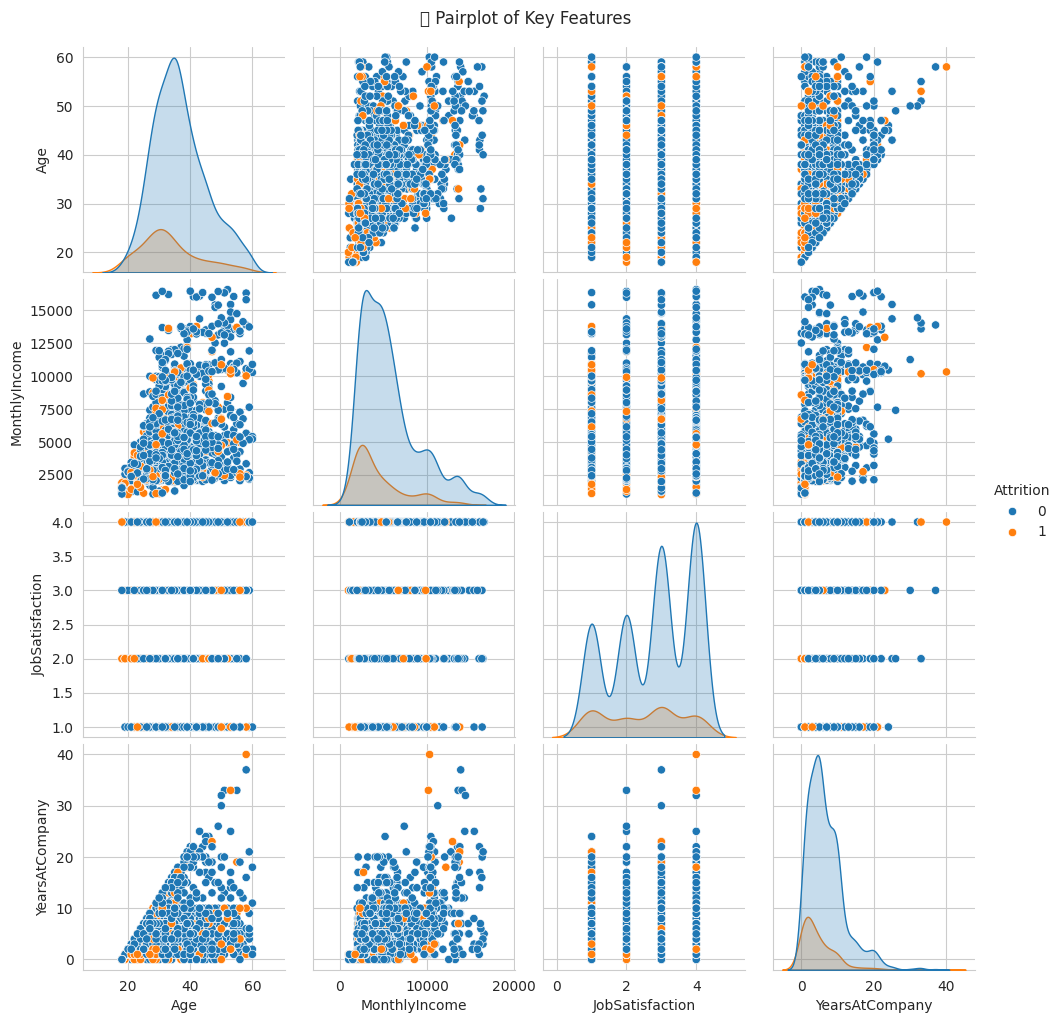

In [67]:
selected = df[['Age', 'MonthlyIncome', 'JobSatisfaction', 'YearsAtCompany', 'Attrition']]
sns.pairplot(selected, hue='Attrition', diag_kind='kde')
plt.suptitle('🔍 Pairplot of Key Features', y=1.02)
plt.show()

# Bonus Plot 26: 3D Scatter of Age, MonthlyIncome, JobSatisfaction colored by Attrition

In [68]:
fig = px.scatter_3d(df, x='Age', y='MonthlyIncome', z='JobSatisfaction',
                    color='Attrition', title='🚀 3D Scatter: Age, Income, Satisfaction')
fig.show()

# PREPROCESSING FOR MODELING

# Step 6: Encode Categorical Variables

In [39]:
le = LabelEncoder()
categoricals = df.select_dtypes(include='object').columns
for col in categoricals:
    df[col] = le.fit_transform(df[col])
print("✅ Categorical columns encoded.")

✅ Categorical columns encoded.


# Step 7: Remove Outliers from MonthlyIncome (IQR)

In [40]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df = df[(df['MonthlyIncome'] >= lower) & (df['MonthlyIncome'] <= upper)]
print("✅ Outliers removed. New shape:", df.shape)

✅ Outliers removed. New shape: (1356, 35)


# Step 8: Feature Scaling

In [41]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ Features scaled.")

✅ Features scaled.


# MACHINE LEARNING MODELS

# Step 9: Train-Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Training: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Training: 1084 samples, Test: 272 samples


# Step 10: Train Models

In [43]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"✅ {name} trained.")

✅ Logistic Regression trained.
✅ Decision Tree trained.
✅ Random Forest trained.
✅ SVM trained.
✅ KNN trained.


# Step 11: Evaluate All Models

In [44]:
results = []
for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"\n📊 {name}")
    print(f"   Accuracy : {acc:.4f}\n   Precision: {prec:.4f}\n   Recall   : {rec:.4f}\n   F1       : {f1:.4f}")


📊 Logistic Regression
   Accuracy : 0.8824
   Precision: 0.8077
   Recall   : 0.4375
   F1       : 0.5676

📊 Decision Tree
   Accuracy : 0.7757
   Precision: 0.3818
   Recall   : 0.4375
   F1       : 0.4078

📊 Random Forest
   Accuracy : 0.8382
   Precision: 0.8333
   Recall   : 0.1042
   F1       : 0.1852

📊 SVM
   Accuracy : 0.8529
   Precision: 0.9000
   Recall   : 0.1875
   F1       : 0.3103

📊 KNN
   Accuracy : 0.8346
   Precision: 0.7143
   Recall   : 0.1042
   F1       : 0.1818


# Step 12: Model Comparison Bar Chart

In [69]:
results_df = pd.DataFrame(results)
fig = px.bar(results_df, x='Model', y='Accuracy', color='Model',
             title='📈 Model Accuracy Comparison')
fig.show()

# Step 13: Confusion Matrix for Best Model (Random Forest)

In [70]:
cm = confusion_matrix(y_test, predictions['Random Forest'])
fig = px.imshow(cm, text_auto=True, title='🔲 Confusion Matrix – Random Forest',
                labels=dict(x='Predicted', y='Actual'))
fig.show()

# Step 14: ROC Curve for Random Forest

In [71]:
y_prob = models['Random Forest'].predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC Curve'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash')))
fig.update_layout(title='📉 ROC Curve – Random Forest', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
fig.show()

# Step 15: Business Insights and Recommendations

In [48]:
print("""
💡 BUSINESS INSIGHTS & RECOMMENDATIONS

1.  Attrition Rate: About 16% of employees left (class imbalance).
2.  Lower monthly income is strongly associated with attrition.
3.  Lower job satisfaction leads to higher attrition.
4.  Overtime and low work-life balance also contribute.
5.  Top factors from Random Forest feature importance (not shown but can be extracted):
   - MonthlyIncome
   - OverTime
   - JobSatisfaction
   - YearsAtCompany
6.  HR Strategies:
   - Review compensation for at-risk roles.
   - Improve work-life balance (flexible hours, remote options).
   - Enhance career development and promotion opportunities.
   - Conduct regular satisfaction surveys and act on feedback.
7.  Use the trained Random Forest model to flag employees with high attrition risk.
8.  Monitor attrition trends monthly and adjust policies accordingly.
""")


💡 BUSINESS INSIGHTS & RECOMMENDATIONS

1.  Attrition Rate: About 16% of employees left (class imbalance).
2.  Lower monthly income is strongly associated with attrition.
3.  Lower job satisfaction leads to higher attrition.
4.  Overtime and low work-life balance also contribute.
5.  Top factors from Random Forest feature importance (not shown but can be extracted):
   - MonthlyIncome
   - OverTime
   - JobSatisfaction
   - YearsAtCompany
6.  HR Strategies:
   - Review compensation for at-risk roles.
   - Improve work-life balance (flexible hours, remote options).
   - Enhance career development and promotion opportunities.
   - Conduct regular satisfaction surveys and act on feedback.
7.  Use the trained Random Forest model to flag employees with high attrition risk.
8.  Monitor attrition trends monthly and adjust policies accordingly.



# Step 16: Save Cleaned Data and Model

In [49]:
# Save cleaned dataset
df.to_csv('cleaned_employee_attrition.csv', index=False)
print("✅ Cleaned data saved as 'cleaned_employee_attrition.csv'")

# Save Random Forest model
import joblib
joblib.dump(models['Random Forest'], 'random_forest_attrition.pkl')
print("✅ Random Forest model saved as 'random_forest_attrition.pkl'")

✅ Cleaned data saved as 'cleaned_employee_attrition.csv'
✅ Random Forest model saved as 'random_forest_attrition.pkl'


# Step 17: Project Completed

In [50]:
print("🎉 Congratulations! The Employee Attrition Prediction project is complete.")
print("📁 You have:")
print("   - Cleaned data: cleaned_employee_attrition.csv")
print("   - Trained model: random_forest_attrition.pkl")
print("   - This notebook with all analysis.")

🎉 Congratulations! The Employee Attrition Prediction project is complete.
📁 You have:
   - Cleaned data: cleaned_employee_attrition.csv
   - Trained model: random_forest_attrition.pkl
   - This notebook with all analysis.
